#Kaggle 2021 Data Science Survey Competition

In [5]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import pandas as pd
import seaborn as sns

In [352]:
dtype_dict = {
    0: str, 18: str, 32: str, 49: str, 56: str, 69: str, 88: str, 100: str, 
    107: str, 113: str, 139: str, 184: str, 195: str, 201: str, 202: str, 
    253: str, 266: str, 278: str, 283: str, 285: str, 286: str, 287: str, 
    288: str, 289: str, 290: str, 291: str, 292: str, 301: str, 322: str, 
    339: str, 347: str, 355: str, 367: str
}

data = pd.read_csv("kaggle_survey_2021_responses.csv", dtype=dtype_dict)

In [353]:
data.head()

,Time from Start to Finish (seconds),Q1,Q2,Q3,Q4,Q5,Q6,Q7_Part_1,Q7_Part_2,Q7_Part_3,...,Q38_B_Part_3,Q38_B_Part_4,Q38_B_Part_5,Q38_B_Part_6,Q38_B_Part_7,Q38_B_Part_8,Q38_B_Part_9,Q38_B_Part_10,Q38_B_Part_11,Q38_B_OTHER
0,Duration (in seconds),What is your age (# years)?,What is your gender? - Selected Choice,In which country do you currently reside?,What is the highest level of formal education ...,Select the title most similar to your current ...,For how many years have you been writing code ...,What programming languages do you use on a reg...,What programming languages do you use on a reg...,What programming languages do you use on a reg...,...,"In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor..."
1,910,50-54,Man,India,Bachelor’s degree,Other,5-10 years,Python,R,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,784,50-54,Man,Indonesia,Master’s degree,Program/Project Manager,20+ years,NaN,NaN,SQL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,924,22-24,Man,Pakistan,Master’s degree,Software Engineer,1-3 years,Python,NaN,NaN,...,NaN,NaN,TensorBoard,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,575,45-49,Man,Mexico,Doctoral degree,Research Scientist,20+ years,Python,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [354]:
data.shape

(25974, 369)

In [355]:
questions = data.iloc[0,:]   # to save first row in splited variable

In [356]:
questions

Time from Start to Finish (seconds)                                Duration (in seconds)
Q1                                                           What is your age (# years)?
Q2                                                What is your gender? - Selected Choice
Q3                                             In which country do you currently reside?
Q4                                     What is the highest level of formal education ...
                                                             ...                        
Q38_B_Part_8                           In the next 2 years, do you hope to become mor...
Q38_B_Part_9                           In the next 2 years, do you hope to become mor...
Q38_B_Part_10                          In the next 2 years, do you hope to become mor...
Q38_B_Part_11                          In the next 2 years, do you hope to become mor...
Q38_B_OTHER                            In the next 2 years, do you hope to become mor...
Name: 0, Length: 369,

In [357]:
data.drop(data.index[0],inplace = True)  #to remove first row

In [364]:
data.head()

,Time from Start to Finish (seconds),Q1,Q2,Q3,Q4,Q5,Q6,Q7_Part_1,Q7_Part_2,Q7_Part_3,...,Q38_B_Part_3,Q38_B_Part_4,Q38_B_Part_5,Q38_B_Part_6,Q38_B_Part_7,Q38_B_Part_8,Q38_B_Part_9,Q38_B_Part_10,Q38_B_Part_11,Q38_B_OTHER
1,910,50-54,Man,India,Bachelor’s degree,Other,5-10 years,Python,R,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,784,50-54,Man,Indonesia,Master’s degree,Program/Project Manager,20+ years,NaN,NaN,SQL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,924,22-24,Man,Pakistan,Master’s degree,Software Engineer,1-3 years,Python,NaN,NaN,...,NaN,NaN,TensorBoard,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,575,45-49,Man,Mexico,Doctoral degree,Research Scientist,20+ years,Python,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,781,45-49,Man,India,Doctoral degree,Other,< 1 years,Python,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [366]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25973 entries, 1 to 25973
Columns: 369 entries, Time from Start to Finish (seconds) to Q38_B_OTHER
dtypes: object(369)
memory usage: 73.1+ MB


In [368]:
data.columns

Index(['Time from Start to Finish (seconds)', 'Q1', 'Q2', 'Q3', 'Q4', 'Q5',
       'Q6', 'Q7_Part_1', 'Q7_Part_2', 'Q7_Part_3',
       ...
       'Q38_B_Part_3', 'Q38_B_Part_4', 'Q38_B_Part_5', 'Q38_B_Part_6',
       'Q38_B_Part_7', 'Q38_B_Part_8', 'Q38_B_Part_9', 'Q38_B_Part_10',
       'Q38_B_Part_11', 'Q38_B_OTHER'],
      dtype='object', length=369)

In [370]:
data["Time from Start to Finish (seconds)"].str.isnumeric() # and put -- .all() -- if you need to overall check

1        True
2        True
3        True
4        True
5        True
         ... 
25969    True
25970    True
25971    True
25972    True
25973    True
Name: Time from Start to Finish (seconds), Length: 25973, dtype: bool

In [372]:
for col in data.columns:
    if data[col].str.isnumeric().all():
        data[col] = pd.to_numeric(data[col])

In [373]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25973 entries, 1 to 25973
Columns: 369 entries, Time from Start to Finish (seconds) to Q38_B_OTHER
dtypes: float64(30), int64(1), object(338)
memory usage: 73.1+ MB


In [374]:
data["Q3"].unique()

array(['India', 'Indonesia', 'Pakistan', 'Mexico', 'Russia', 'Turkey',
       'Australia', 'Nigeria', 'Greece', 'Belgium', 'Japan', 'Egypt',
       'Singapore', 'Brazil', 'Poland', 'China',
       'Iran, Islamic Republic of...', 'United States of America',
       'Italy', 'Viet Nam', 'Israel', 'Peru', 'South Africa', 'Other',
       'Spain', 'Bangladesh',
       'United Kingdom of Great Britain and Northern Ireland', 'France',
       'Switzerland', 'Algeria', 'Tunisia', 'Argentina', 'Sweden',
       'Colombia', 'I do not wish to disclose my location', 'Canada',
       'Chile', 'Netherlands', 'Ukraine', 'Saudi Arabia', 'Romania',
       'Morocco', 'Austria', 'Taiwan', 'Kenya', 'Belarus', 'Ireland',
       'Portugal', 'Hong Kong (S.A.R.)', 'Denmark', 'Germany',
       'South Korea', 'Philippines', 'Sri Lanka', 'United Arab Emirates',
       'Uganda', 'Ghana', 'Malaysia', 'Thailand', 'Nepal', 'Kazakhstan',
       'Ethiopia', 'Iraq', 'Ecuador', 'Norway', 'Czech Republic'],
      dtype=obje

In [375]:
# Example: arab_countries should be a list or a similar list-like object
arab_countries = ['Algeria', 'Bahrain', 'Comoros', 'Djibouti', 'Egypt', 'Iraq', 'Jordan', 'Kuwait', 'Lebanon', 'Libya', 'Mauritania', 'Morocco', 'Oman', 'Palestine', 'Qatar', 'Saudi Arabia', 'Somalia', 'Sudan', 'Syria', 'Tunisia', 'United Arab Emirates', 'Yemen']

# Now you can use isin() without errors
data_arabs = data[data['Q3'].isin(arab_countries)]

In [376]:
data_arabs

,Time from Start to Finish (seconds),Q1,Q2,Q3,Q4,Q5,Q6,Q7_Part_1,Q7_Part_2,Q7_Part_3,...,Q38_B_Part_3,Q38_B_Part_4,Q38_B_Part_5,Q38_B_Part_6,Q38_B_Part_7,Q38_B_Part_8,Q38_B_Part_9,Q38_B_Part_10,Q38_B_Part_11,Q38_B_OTHER
20,650,30-34,Man,Egypt,Bachelor’s degree,Other,< 1 years,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34,744,30-34,Woman,Egypt,Bachelor’s degree,Data Analyst,3-5 years,Python,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
37,244,25-29,Woman,Egypt,Master’s degree,Currently not employed,< 1 years,Python,NaN,SQL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
48,453,18-21,Woman,Egypt,Bachelor’s degree,Student,1-3 years,Python,R,NaN,...,NaN,NaN,TensorBoard,NaN,NaN,NaN,NaN,MLflow,NaN,NaN
85,161,25-29,Man,Algeria,Professional doctorate,Student,I have never written code,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25707,839,18-21,Man,United Arab Emirates,Bachelor’s degree,Student,3-5 years,Python,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25807,733,22-24,Woman,Egypt,Master’s degree,Software Engineer,5-10 years,Python,R,SQL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25831,744,18-21,Woman,Egypt,Bachelor’s degree,Student,< 1 years,Python,NaN,SQL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25875,534,22-24,Man,Egypt,Some college/university study without earning ...,Student,3-5 years,Python,NaN,NaN,...,Comet.ml,Sacred + Omniboard,TensorBoard,Guild.ai,Polyaxon,ClearML,Domino Model Monitor,MLflow,NaN,NaN


In [377]:
data_arabs['Q3'].unique()

array(['Egypt', 'Algeria', 'Tunisia', 'Saudi Arabia', 'Morocco',
       'United Arab Emirates', 'Iraq'], dtype=object)

In [378]:
######################################## line plot

In [379]:
ages = data_arabs['Q1'].value_counts().sort_index()

In [380]:
ages

Q1
18-21    179
22-24    250
25-29    190
30-34    130
35-39    109
40-44     74
45-49     45
50-54     23
55-59      8
60-69     10
Name: count, dtype: int64

In [390]:
x= ages.index
y = ages.values

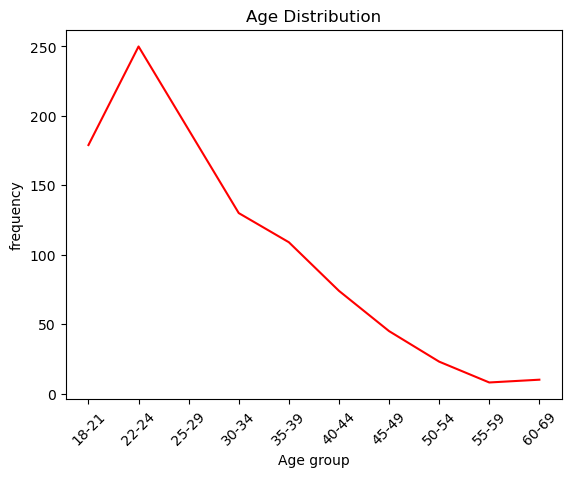

In [392]:
relation = plt.plot(x ,y,color = 'r')
title = plt.title('Age Distribution')
xlabel = plt.xlabel('Age group')
ylabel = plt.ylabel('frequency')
plt.xticks(rotation =45)
plt.show()

In [394]:
countries = data_arabs['Q3'].value_counts()
countries

Q3
Egypt                   482
Morocco                 140
United Arab Emirates    111
Tunisia                 109
Saudi Arabia             89
Algeria                  44
Iraq                     43
Name: count, dtype: int64

In [396]:
countries = data_arabs['Q3'].value_counts()

In [398]:
v = countries.values  
z = countries.index

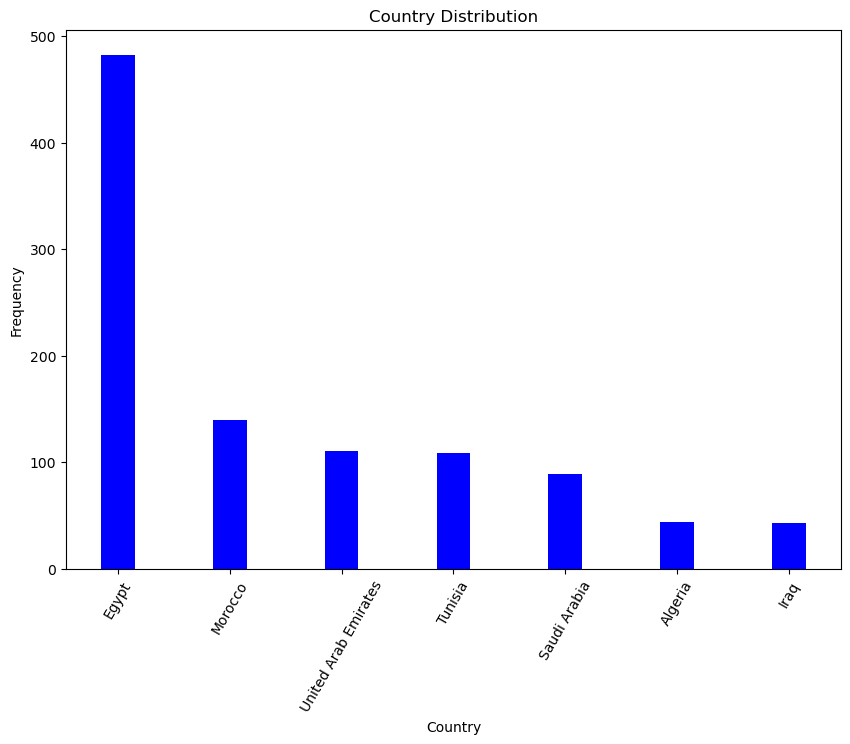

In [453]:
plt.figure(figsize = (10,7))
plt.bar(z,v, color = 'blue',width = .3)
plt.title("Country Distribution")
xlabel = plt.xlabel('Country')
ylabel = plt.ylabel('Frequency')
plt.xticks(rotation = 60)
plt.show()

In [402]:
Q7_columns =  data.columns[data.columns.str.contains('^Q7')]
Q7_columns

Index(['Q7_Part_1', 'Q7_Part_2', 'Q7_Part_3', 'Q7_Part_4', 'Q7_Part_5',
       'Q7_Part_6', 'Q7_Part_7', 'Q7_Part_8', 'Q7_Part_9', 'Q7_Part_10',
       'Q7_Part_11', 'Q7_Part_12', 'Q7_OTHER'],
      dtype='object')

In [404]:
data['Q7_Part_1'].value_counts().values[0]

21860

In [406]:
dic_7 = dict()
for col in Q7_columns:
    value_counts = data[col].value_counts()  # Compute value counts once
    if not value_counts.empty:  # Check if the column has values
        key = value_counts.index[0]  # Most frequent value
        dic_7[key] = value_counts.iloc[0]  # Corresponding count
    else:
        dic_7['None'] = 319  # Handle empty columns (optional)
dic_7

{'Python': 21860,
 'R': 5334,
 'SQL': 10756,
 'C': 4709,
 'C++': 5535,
 'Java': 4769,
 'Javascript': 4332,
 'Julia': 305,
 'Swift': 242,
 'Bash': 2216,
 'MATLAB': 2935,
 'None': 319,
 'Other': 2575}

In [408]:
question_7_series  = pd.Series(dic_7)

In [473]:
question_7_series.sort_values(ascending = False)    #### sort values

Python        21860
SQL           10756
C++            5535
R              5334
Java           4769
C              4709
Javascript     4332
MATLAB         2935
Other          2575
Bash           2216
None            319
Julia           305
Swift           242
dtype: int64

In [475]:
question_7_series.index

Index(['Python', 'R', 'SQL', 'C', 'C++', 'Java', 'Javascript', 'Julia',
       'Swift', 'Bash', 'MATLAB', 'None', 'Other'],
      dtype='object')

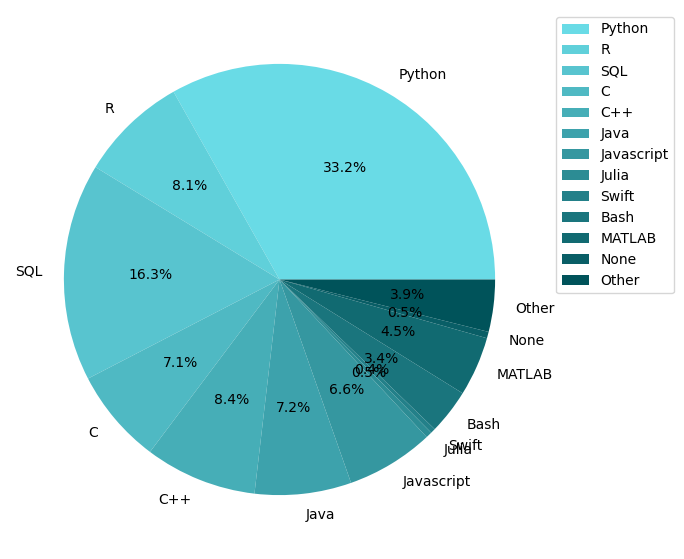

In [477]:
start_color = "#69DBE6"  # Light blue
end_color = "#00535A"    # Dark blue

# Create a custom colormap with only the start and end colors
cmap = LinearSegmentedColormap.from_list("custom_gradient", [start_color, end_color], N=13)

# Generate a list of 13 colors from the colormap
pie_colors = [cmap(i) for i in np.linspace(0, 1, 13)]

# Plot the pie chart
plt.figure(figsize=(10, 7))
plt.pie(sizes, labels=labels, autopct="%1.1f%%", colors=pie_colors)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1)) 
plt.show()

Text(0.5, 1.0, 'Programming language Distrribution for Kaggle users')

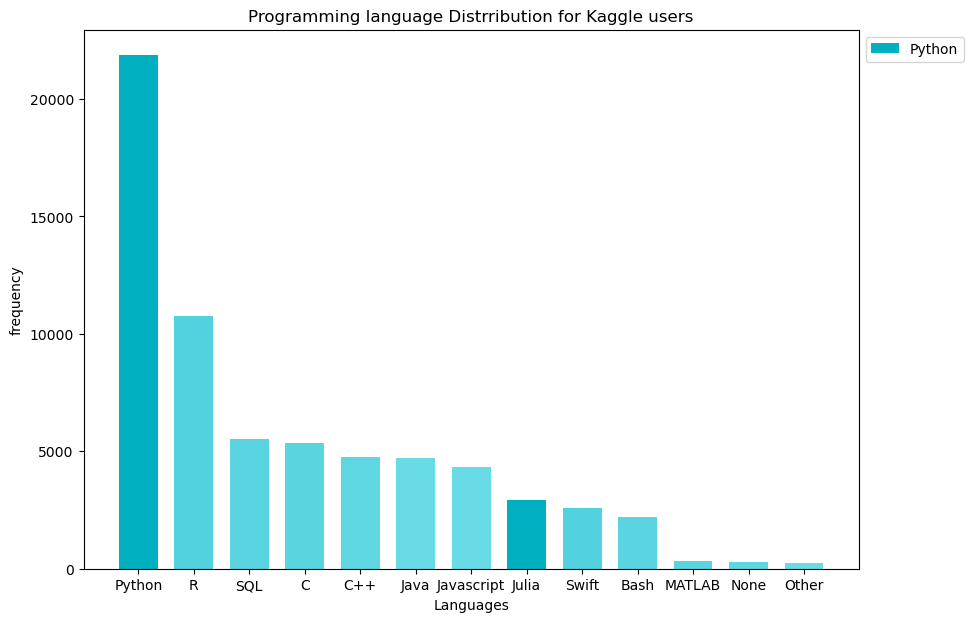

In [483]:
plt.figure(figsize=(10, 7))
bars = plt.bar(labels, question_7_series.sort_values(ascending = False), color=bar_colors, width = .7)

# Add value labels on top of each bar


# Add legend and labels
plt.legend(labels, loc='upper left', bbox_to_anchor=(1, 1))
plt.xlabel('Languages')
plt.ylabel('frequency')
plt.title('Programming language Distrribution for Kaggle users')